In [1]:
%matplotlib inline
from os.path import join as opj
import json
from nipype.interfaces.spm import Level1Design, EstimateModel, EstimateContrast
from nipype.algorithms.modelgen import SpecifySPMModel
from nipype.interfaces.utility import Function, IdentityInterface
from nipype.interfaces.io import SelectFiles, DataSink
from nipype import Workflow, Node

230320-14:49:47,491 nipype.utils WARNING:
	 A newer version (1.8.4) of nipy/nipype is available. You are using 1.8.3


In [2]:
experiment_dir = '/Users/mrenke/data/ds-stressrisk/derivatives/fmriprep'
output_dir = '/Users/mrenke/data/ds-stressrisk/derivatives/nipype_glm'
working_dir = '/Users/mrenke/data/ds-stressrisk/derivatives/nipype_glm_workingdir'

# list of subject identifiers
subject_list = ['01']

# TR of functional images
fson_f = '/Users/mrenke/data/ds-stressrisk/derivatives/fmriprep/sub-01/ses-1/func/sub-01_ses-1_task-risk_run-1_space-fsaverage_hemi-L_bold.json'
with open(fson_f, 'rt') as fp: #fson_f
    task_info = json.load(fp)
TR = task_info['RepetitionTime']
TR


2.298

In [12]:
# SpecifyModel - Generates SPM-specific Model
modelspec = Node(SpecifySPMModel(concatenate_runs=False,
                                 input_units='secs',
                                 output_units='secs',
                                 time_repetition=TR,
                                 high_pass_filter_cutoff=128),
                 name="modelspec")

# Level1Design - Generates an SPM design matrix
level1design = Node(Level1Design(bases={'hrf': {'derivs': [1, 0]}},
                                 timing_units='secs',
                                 interscan_interval=TR,
                                 model_serial_correlations='FAST'),
                    name="level1design")

# EstimateModel - estimate the parameters of the model
level1estimate = Node(EstimateModel(estimation_method={'Classical': 1}),
                      name="level1estimate")

# EstimateContrast - estimates contrasts
level1conest = Node(EstimateContrast(), name="level1conest")

In [13]:
# Condition names
condition_names = ['risky', 'safe']
condition_names = ['risky_first',  'risky_second', 'safe_first','safe_second']


# Contrasts
cont01 = ['average',        'T', condition_names, [1/4., 1/4., 1/4., 1/4.]]
cont02 = ['risky_first',         'T', condition_names, [1, 0, 0, 0]]
cont03 = ['risky_second',           'T', condition_names, [0, 1, 0, 0]]
cont04 = ['safe_first',           'T', condition_names, [0, 0, 1, 0]]
cont05 = ['safe_second',           'T', condition_names, [0, 0, 0, 1]]

# cont05 = ['Finger > others','T', condition_names, [1, -0.5, -0.5]]
# cont08 = ['activation',     'F', [cont02, cont03, cont04]]
# cont09 = ['differences',    'F', [cont05, cont06, cont07]]
contrast_list = [cont01, cont02, cont03, cont04, cont05]

In [14]:
!cat /Users/mrenke/data/ds-stressrisk/sub-01/ses-1/func/sub-01_ses-1_task-risk_run-1_events.tsv

trial_nr	onset	trial_type	prob1	prob2	n1	n2	choice
1	13.262185600000521	stimulus 1	0.55	1.0	13.0	10.0	
1	19.467741299999034	stimulus 2	0.55	1.0	13.0	10.0	
1	19.94471500000145	choice					2.0
2	25.923746000000378	stimulus 1	0.55	1.0	8.0	7.0	
2	35.11559309999937	stimulus 2	0.55	1.0	8.0	7.0	
2	35.620652400000836	choice					2.0
3	42.072033699998414	stimulus 1	0.55	1.0	13.0	7.0	
3	51.26377380000122	stimulus 2	0.55	1.0	13.0	7.0	
3	51.87303350000002	choice					1.0
4	57.219389999998384	stimulus 1	0.55	1.0	38.0	28.0	
4	64.40938340000139	stimulus 2	0.55	1.0	38.0	28.0	
4	64.93152750000081	choice					2.0
5	70.3649035999988	stimulus 1	0.55	1.0	16.0	10.0	
5	76.57063280000148	stimulus 2	0.55	1.0	16.0	10.0	
5	77.1789299000011	choice					1.0
6	82.5094691000013	stimulus 1	0.55	1.0	32.0	14.0	
6	91.71786760000032	stimulus 2	0.55	1.0	32.0	14.0	
6	92.64040920000116	choice					1.0
7	99.15822610000032	stimulus 1	0.55	1.0	46.0	20.0	
7	106.36488810000083	stimulus 2	0.55	1.0	46.0	20.0	
7	107.40409759999963	choice

In [15]:
import pandas as pd
events_f = '/Users/mrenke/data/ds-stressrisk/sub-01/ses-1/func/sub-01_ses-1_task-risk_run-1_events.tsv'
trialinfo = pd.read_table(events_f)
# for group in trialinfo.groupby('trial_type'):
trialinfo['trial_type'].unique()


array(['stimulus 1', 'stimulus 2', 'choice'], dtype=object)

In [16]:
# Smoothing withds used during preprocessing
fwhm = [4, 8]

substitutions = [('_subject_id_', 'sub-')]
subjFolders = [('_fwhm_id_%ssub-%s' % (f, sub) , 'sub-%s/fwhm-%s' % (sub, f))
               for f in fwhm
               for sub in subject_list]

subjFolders
               

[('_fwhm_id_4sub-01', 'sub-01/fwhm-4'), ('_fwhm_id_8sub-01', 'sub-01/fwhm-8')]

In [17]:
import os.path as op
bids_folder = '/Users/mrenke/data/ds-stressrisk'

def subjectinfo(subject_id):
    sub = subject_id
    ses = 1
    import pandas as pd
    from nipype.interfaces.base import Bunch

    trialinfo = pd.read_table(op.join(bids_folder,f'sub-{sub}', f'sub-{ses}', 'func', f'sub-{sub}_ses-{ses}_task-risk_run-1_events.tsv'))
    trialinfo.head()
    conditions = []
    onsets = []
    durations = []

    for group in trialinfo.groupby('trial_type'):
        conditions.append(group[0])
        onsets.append(list(group[1].onset - 10)) # subtracting 10s due to removing of 4 dummy scans
        #durations.append(group[1].duration.tolist())

    subject_info = [Bunch(conditions=conditions,
                          onsets=onsets
                          #durations=durations,
                          #amplitudes=None,
                          #tmod=None,
                          #pmod=None,
                          #regressor_names=None,
                          #regressors=None
                         )]

    return subject_info  # this output will later be returned to infosource


# Get Subject Info - get subject specific condition information
getsubjectinfo = Node(Function(input_names=['subject_id'],
                               output_names=['subject_info'],
                               function=subjectinfo),
                      name='getsubjectinfo')

In [18]:
# Infosource - a function free node to iterate over the list of subject names
infosource = Node(IdentityInterface(fields=['subject_id',
                                            'contrasts'],
                                    contrasts=contrast_list),
                  name="infosource")
infosource.iterables = [('subject_id', subject_list)]

# SelectFiles - to grab the data (alternativ to DataGrabber)
templates = {'func': opj(output_dir, 'preproc', 'sub-{subject_id}', 'task-{task_id}',
                         'sub-{subject_id}_ses-{session_id}_task-{task_id}_bold.nii'),
             'mc_param': opj(output_dir, 'preproc', 'sub-{subject_id}', 'task-{task_id}',
                             'sub-{subject_id}_ses-{session_id}_task-{task_id}_bold.par'),
             'outliers': opj(output_dir, 'preproc', 'sub-{subject_id}', 'task-{task_id}',
                             'art.sub-{subject_id}_ses-{session_id}_task-{task_id}_bold_outliers.txt')}
                             
selectfiles = Node(SelectFiles(templates,
                               base_directory=experiment_dir,
                               sort_filelist=True),
                   name="selectfiles")
selectfiles.inputs.task_id = 'risk'
selectfiles.inputs.session_id = '1'


# Datasink - creates output folder for important outputs
datasink = Node(DataSink(base_directory=experiment_dir,
                         container=output_dir),
                name="datasink")

# Use the following DataSink output substitutions
substitutions = [('_subject_id_', 'sub-')]
subjFolders = [('_fwhm_id_%ssub-%s' % (f, sub), 'sub-%s/fwhm-%s' % (sub, f))
               for f in fwhm
               for sub in subject_list]
substitutions.extend(subjFolders)
datasink.inputs.substitutions = substitutions

In [19]:
# Initiation of the 1st-level analysis workflow
l1analysis = Workflow(name='l1analysis')
l1analysis.base_dir = opj(experiment_dir, working_dir)

# Connect up the 1st-level analysis components
l1analysis.connect([(infosource, selectfiles, [('subject_id', 'subject_id'),
                                               ('fwhm_id', 'fwhm_id')]),
                    (infosource, getsubjectinfo, [('subject_id',
                                                   'subject_id')]),
                    (getsubjectinfo, modelspec, [('subject_info',
                                                  'subject_info')]),
                    (infosource, level1conest, [('contrasts', 'contrasts')]),
                    (selectfiles, modelspec, [('func', 'functional_runs')]),
                    (selectfiles, modelspec, [('mc_param', 'realignment_parameters'),
                                              ('outliers', 'outlier_files')]),
                    (modelspec, level1design, [('session_info',
                                                'session_info')]),
                    (level1design, level1estimate, [('spm_mat_file',
                                                     'spm_mat_file')]),
                    (level1estimate, level1conest, [('spm_mat_file',
                                                     'spm_mat_file'),
                                                    ('beta_images',
                                                     'beta_images'),
                                                    ('residual_image',
                                                     'residual_image')]),
                    (level1conest, datasink, [('spm_mat_file', '1stLevel.@spm_mat'),
                                              ('spmT_images', '1stLevel.@T'),
                                              ('con_images', '1stLevel.@con'),
                                              ('spmF_images', '1stLevel.@F'),
                                              ('ess_images', '1stLevel.@ess'),
                                              ]),
                    ])

230320-14:53:55,930 nipype.workflow INFO:
	 Generated workflow graph: /Users/mrenke/data/ds-stressrisk/derivatives/nipype_glm_workingdir/l1analysis/graph.png (graph2use=colored, simple_form=True).


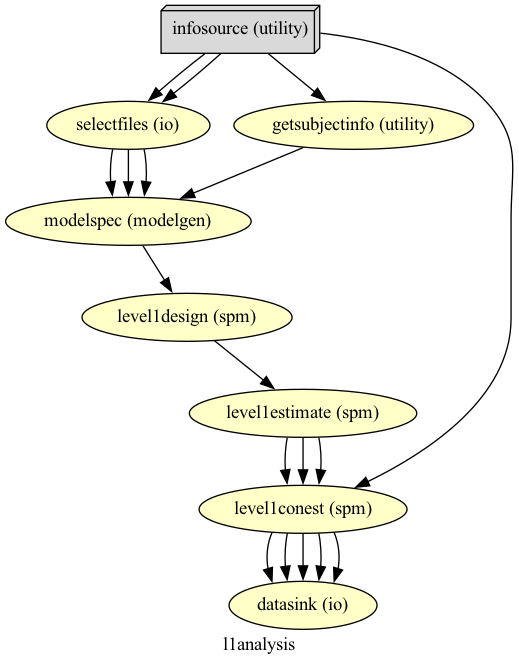

In [20]:
# Create 1st-level analysis output graph
l1analysis.write_graph(graph2use='colored', format='png', simple_form=True)

# Visualize the graph
from IPython.display import Image
Image(filename=opj(l1analysis.base_dir, 'l1analysis', 'graph.png'))

In [21]:
l1analysis.run('MultiProc', plugin_args={'n_procs': 8})


230320-14:54:47,307 nipype.workflow INFO:
	 Workflow l1analysis settings: ['check', 'execution', 'logging', 'monitoring']


AttributeError: 'DynamicTraitedSpec' object has no attribute 'fwhm_id'